In [2]:
import os
import pandas as pd
import cv2
import torch
import torch.nn.utils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
import json
print("All modules imported")

All modules imported


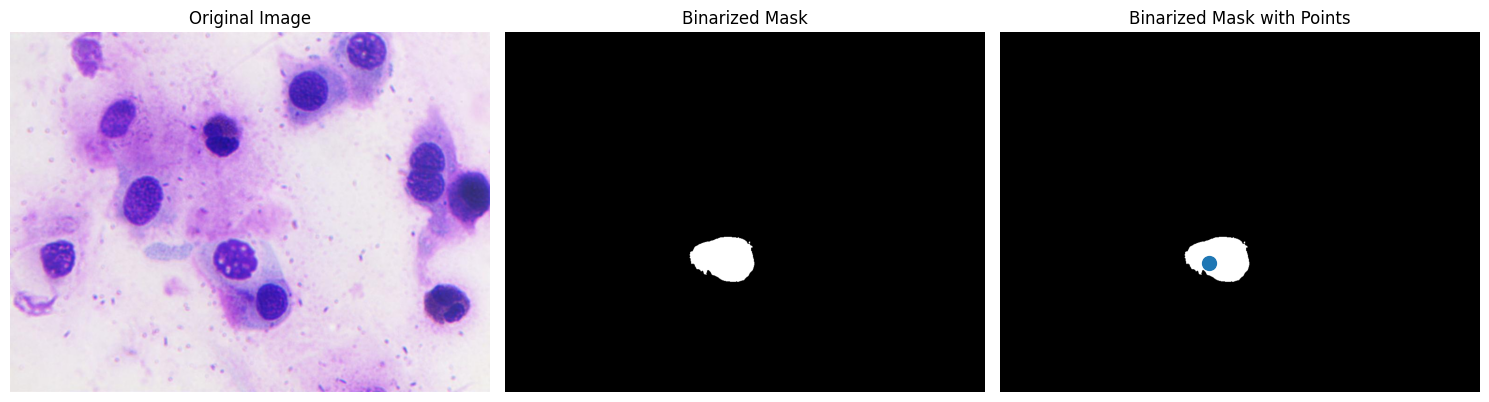

In [3]:
data_dir = r"C:\Users\Admin\Desktop\New_Dataset"
images_dir = os.path.join(data_dir, "images")
masks_dir = os.path.join(data_dir, "masks")

with open(r"C:\Users\Admin\Desktop\New_Dataset\labels.json") as f:
    data=json.load(f)

all_data = []
all_images=[]
for entry in data['images']:
    image_name = entry['image_name']
    masks = [label['mask_file'] for label in entry['labels']]
    
    all_images.append({
        "image": os.path.join(images_dir, image_name),
        "masks": [os.path.join(masks_dir, mask) for mask in masks],
        "labels": [label['label'] for label in entry['labels']]
    })

train_images, test_images = train_test_split(all_images, test_size=0.2, random_state=42)

train_data = []
for entry in train_images:
    for mask in entry['masks']:
        train_data.append({
            "image": entry["image"],
            "annotation": mask
        })

test_data = []
for entry in test_images:
    for mask in entry['masks']:
        test_data.append({
            "image": entry["image"],
            "annotation": mask
        })
        
def read_batch(data, visualize_data=False):
    # Select a random entry
    ent = data[np.random.randint(len(data))]

    # Get full paths
    Img = cv2.imread(ent["image"])[..., ::-1]  # Convert BGR to RGB
    ann_map = cv2.imread(ent["annotation"], cv2.IMREAD_GRAYSCALE)  # Read annotation as grayscale

    if Img is None or ann_map is None:
        print(f"Error: Could not read image or mask from path {ent['image']} or {ent['annotation']}")
        return None, None, None, 0

    # Resize image and mask
    r = np.min([1024 / Img.shape[1], 1024 / Img.shape[0]])  # Scaling factor
    Img = cv2.resize(Img, (int(Img.shape[1] * r), int(Img.shape[0] * r)))
    ann_map = cv2.resize(ann_map, (int(ann_map.shape[1] * r), int(ann_map.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
    binary_mask = np.zeros_like(ann_map, dtype=np.uint8)
    points=[]
    inds = np.unique(ann_map)[1:]
    for ind in inds:
        mask = (ann_map == ind).astype(np.uint8)
        binary_mask = np.maximum(binary_mask, mask)
    coords = np.argwhere(binary_mask > 0)
    if len(coords) > 0:
        for _ in inds:
            yx = np.array(coords[np.random.randint(len(coords))])
            points.append([yx[1], yx[0]])
    points = np.array(points)

    if visualize_data:
        # Plotting the images and points
        plt.figure(figsize=(15, 5))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.title('Original Image')
        plt.imshow(Img)
        plt.axis('off')
        # Segmentation Mask (binary_mask)
        plt.subplot(1, 3, 2)
        plt.title('Binarized Mask')
        plt.imshow(binary_mask, cmap='gray')
        plt.axis('off')

        # Mask with Points in Different Colors
        plt.subplot(1, 3, 3)
        plt.title('Binarized Mask with Points')
        plt.imshow(binary_mask, cmap='gray')
        colors = list(mcolors.TABLEAU_COLORS.values())
        for i, point in enumerate(points):
            plt.scatter(point[0], point[1], c=colors[i % len(colors)], s=100, label=f'Point {i+1}')  # Corrected to plot y, x order

        # plt.legend()
        plt.axis('off')

        plt.tight_layout()
        plt.show()
        
    binary_mask = np.expand_dims(binary_mask, axis=-1)  # Now shape is (1024, 1024, 1)
    binary_mask = binary_mask.transpose((2, 0, 1))
    points = np.expand_dims(points, axis=1)

    # Return the image, binarized mask, points, and number of masks
    return Img, binary_mask, points, len(inds)

Img1, masks1, points1, num_masks = read_batch(train_data, visualize_data=True)


In [4]:
def read_image(image_path, mask_path):  # read and resize image and mask
    img = cv2.imread(image_path)[..., ::-1]  # Convert BGR to RGB
    mask = cv2.imread(mask_path, 0)
    r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])
    img = cv2.resize(img, (int(img.shape[1] * r), int(img.shape[0] * r)))
    mask = cv2.resize(mask, (int(mask.shape[1] * r), int(mask.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
    return img, mask

def get_points(mask, num_points):  # Sample points inside the input mask
    points = []
    coords = np.argwhere(mask > 0)
    for i in range(num_points):
        yx = np.array(coords[np.random.randint(len(coords))])
        points.append([[yx[1], yx[0]]])
    return np.array(points)

In [ ]:
all_data = []

import albumentations as A
from albumentations.pytorch import ToTensorV2
import random
from PIL import Image
from torchvision import transforms


for entry in data['images']:
    image_name = entry['image_name']
    image_path = os.path.join(images_dir, image_name)

    image = Image.open(image_path).convert("RGB")

    for label_info in entry['labels']:
        mask_path = os.path.join(masks_dir, label_info['mask_file'])
        label = label_info['label']

        mask = Image.open(mask_path).convert("L")

        masked_image = Image.composite(image, Image.new("RGB", image.size), mask)
        masked_image = np.array(masked_image)

        all_data.append({"masked_image": masked_image, "label": label})


t_all_data=[]
test_root_dir=r"C:\Users\Admin\Desktop\New_Test_Dataset"
t_images_dir=os.path.join(test_root_dir,"images")
t_masks_dir=os.path.join(test_root_dir, "masks")
t_data_dir=os.path.join(test_root_dir, "labels.json")
with open(t_data_dir) as f:
    t_data=json.load(f)
    
for entry in t_data['images']:
    image_name= entry['image_name']
    image_path= os.path.join(t_images_dir, image_name)

    image=Image.open(image_path).convert("RGB")

    for label_info in entry['labels']:
        mask_path=os.path.join(t_masks_dir, label_info['mask_file'])
        label=label_info['label']

        mask=Image.open(mask_path).convert("L")

        masked_image = Image.composite(image, Image.new("RGB", image.size), mask)
        masked_image = np.array(masked_image)

        t_all_data.append({"masked_image":masked_image, "label":label})


    
random.shuffle(all_data)
train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=42)

class MaskedImageDataset(torch.utils.data.Dataset):
    def __init__(self, data, transform=None, augmentations=None, num_copies=1):
        self.data = data
        self.transform = transform
        self.augmentations = augmentations
        self.num_copies = num_copies
        self.expanded_data = self._expand_data()

    def _expand_data(self):
        expanded_data = []
        for item in self.data:
            expanded_data.append(item)
            for _ in range(self.num_copies - 1):
                augmented_item = item.copy()
                image = item["masked_image"]
                
                if not isinstance(image, np.ndarray):
                    image = np.array(image)

                augmented_data = self.augmentations(image=image)
                augmented_item["masked_image"] = augmented_data["image"]
                expanded_data.append(augmented_item)
                
        return expanded_data

    def __getitem__(self, idx):
        item = self.expanded_data[idx]
        masked_image = item["masked_image"]
        label = item["label"]


        if self.augmentations and isinstance(masked_image, np.ndarray):
            masked_image = np.array(masked_image)

        if self.augmentations:
            augmented = self.augmentations(image=masked_image)
            masked_image = augmented["image"]
            
        masked_image=torch.tensor(masked_image, dtype=torch.float32)

        if self.transform and not isinstance(masked_image, torch.Tensor):
            masked_image = self.transform(masked_image)
        
        return masked_image, label

    def __len__(self):
        return len(self.expanded_data)
        
albumentations_augmentations = A.Compose([
    A.RandomBrightnessContrast(p=1.0),
    A.VerticalFlip(p=1.0),
    A.Rotate(p=1.0)
])

torchvision_transform = transforms.Compose([
    transforms.ToTensor(),
    ToTensorV2()
])


train_dataset = MaskedImageDataset(
    train_data, 
    transform=torchvision_transform, 
    augmentations=albumentations_augmentations, 
    num_copies=3
)

test_dataset = MaskedImageDataset(
    test_data, 
    transform=torchvision_transform 
)

final_test_dataset= MaskedImageDataset(
    t_all_data,
    transform=torchvision_transform
)

final_test_loader=torch.utils.data.DataLoader(final_test_dataset, batch_size=4, shuffle=True)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=True)

In [46]:
len(final_test_loader)

266

torch.Size([768, 1024, 3])


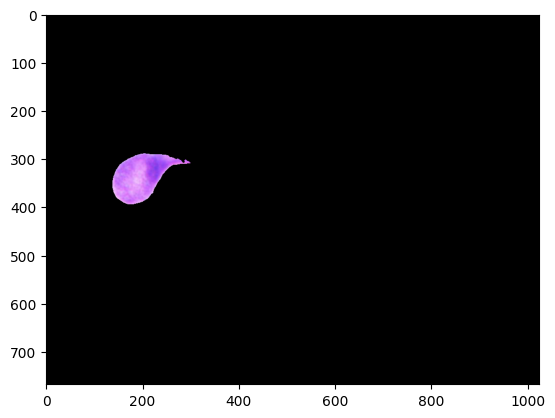

In [62]:
import cv2
data_iter = iter(final_test_loader)
images, labels = next(data_iter)

image = images[2]
label = labels[2]
print(image.shape) 

image=image.numpy()

image_np = (image * 1).astype(np.uint8)

plt.imshow(image_np)
plt.show()

In [72]:
image=torch.tensor(image)
print(image.shape)

torch.Size([3, 768, 1024])


C:\Users\Admin\AppData\Local\Temp\ipykernel_9248\2586896900.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image=torch.tensor(image)


In [ ]:
from torch.optim import SGD, Adam
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

k=4
batch_size=4
fold_train_accuracies = []
fold_val_accuracies = []
fold_test_accuracies = []

dataset = train_dataset

kf = KFold(n_splits=k, shuffle=True, random_state=42)

num_classes = len(set(label for entry in train_images for label in entry["labels"]))
classifier = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', pretrained=True)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classifier.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(classifier.parameters(), lr=0.00005)
num_epochs = 30

label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
                 "mast cell": 9, "lymphocyte": 10}

train_accuracies, test_accuracies, train_losses = [], [], []
checkpoint_dir = r"C:\Users\Admin\Documents\mnet_checks"

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    best_fva=0
    print(f"\n=== Fold {fold+1}/{k} ===")

    train_subset = torch.utils.data.Subset(dataset, train_idx)
    val_subset = torch.utils.data.Subset(dataset, val_idx)
    train_loader_kfold = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader_kfold = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    # Reinitializing model, optimizer, scheduler and criterion for each fold
    classifier = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', pretrained=True)
    classifier.fc = nn.Sequential(
        nn.Linear(classifier.last_channel, 512),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(512, num_classes)
    )
    classifier.to(device)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(classifier.parameters(), lr=0.00005)

    # Training Loop
    fold_train_accuracy = []
    fold_val_accuracy = []

    for epoch in range(num_epochs):
        classifier.train()
        running_loss = 0.0
        correct_predictions = 0
        total_predictions = 0
        total_val_loss=0.0

        progress_bar = tqdm(train_loader_kfold, desc=f"Fold {fold+1} Epoch {epoch+1}/{num_epochs}", leave=False)
        
        # Processing one epoch within each fold
        for masked_images, labels in progress_bar:
            masked_images = masked_images.permute(0, 3, 1, 2)
            masked_images = masked_images.to(device)
            optimizer.zero_grad()

            outputs = classifier(masked_images)
            numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
            loss = criterion(outputs, numeric_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == numeric_labels).sum().item()
            total_predictions += len(numeric_labels)

            avg_loss = running_loss / total_predictions
            accuracy = correct_predictions / total_predictions * 100
            progress_bar.set_postfix(loss=avg_loss, accuracy=f"{accuracy:.2f}%")
            
        # Printing epoch metrics
        print(f"Fold {fold+1} Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}, Training Accuracy: {accuracy:.2f}%")
        fold_train_accuracy.append(accuracy)  # Appending accuracy of each epoch to one list
        
        # Getting validation results for the epoch
        classifier.eval()
        correct_val_predictions, total_val_predictions = 0, 0
        with torch.no_grad():
            for masked_images, labels in val_loader_kfold:
                masked_images = masked_images.permute(0, 3, 1, 2)
                masked_images = masked_images.to(device)
                outputs = classifier(masked_images)
                numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
                _, predicted = torch.max(outputs, 1)
                correct_val_predictions += (predicted == numeric_labels).sum().item()
                total_val_predictions += len(numeric_labels)
                loss = criterion(outputs, numeric_labels)
                total_val_loss += loss.item()

        average_val_loss = total_val_loss / len(val_loader_kfold)
        scheduler.step(average_val_loss) # Implementing Reduce LR On Plateau here
        val_accuracy = correct_val_predictions / total_val_predictions * 100
        print(f"Epoch validation accuracy: {val_accuracy:.3f}")
        fold_val_accuracy.append(val_accuracy) # Appending epoch validation accuracy to one list
        if val_accuracy>best_fva:
            best_fva=val_accuracy
            checkpoint_path = os.path.join(checkpoint_dir, f"classifier_epoch_{epoch+1}_fold{fold+1}_{val_accuracy:.3f}.pth") # Saving
            torch.save(classifier.state_dict(), checkpoint_path)
            
    # Appending the list of all epoch accuracies in a fold to another list of fold accuracies
    fold_train_accuracies.append(fold_train_accuracy)
    fold_val_accuracies.append(fold_val_accuracy)

    # Evaluation on test_loader, once per each fold
    correct_test_predictions, total_test_predictions = 0, 0
    classifier.eval()
    with torch.no_grad():
        for masked_images, labels in test_loader:
            masked_images=masked_images.permute(0,3,1,2)
            masked_images = masked_images.to(device)
            outputs = classifier(masked_images)
            numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
            _, predicted = torch.max(outputs, 1)
            correct_test_predictions += (predicted == numeric_labels).sum().item()
            total_test_predictions += len(numeric_labels)

    test_accuracy = correct_test_predictions / total_test_predictions * 100
    fold_test_accuracies.append(test_accuracy)
    # checkpoint_path = os.path.join(checkpoint_dir, f"classifier_epoch_{epoch+1}_TA_{test_accuracy}_FVA_{fold_val_accuracy[-1]}.pth")
    # Printing the fold's best validation and test accuracy
    print(f"Fold {fold+1} Validation Accuracy: {fold_val_accuracy[-1]:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

# Cross-Validation Summary
print("\n=== Cross-Validation Results ===")
avg_val_accuracy = sum([acc[-1] for acc in fold_val_accuracies]) / k
avg_test_accuracy = sum(fold_test_accuracies) / k
print(f"Average Validation Accuracy: {avg_val_accuracy:.2f}%")
print(f"Average Test Accuracy: {avg_test_accuracy:.2f}%")

plt.figure(figsize=(10, 6))
for fold_idx, train_acc in enumerate(fold_train_accuracies):
    plt.plot(range(1, num_epochs + 1), train_acc, label=f"Fold {fold_idx + 1} Training Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracies Across Folds')
plt.show()

In [74]:
label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
                 "mast cell": 9, "lymphocyte": 10}

model=torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', pretrained=True)
model.fc = nn.Sequential(
        nn.Linear(classifier.last_channel, 512),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(512, num_classes))
saved_model_path=r"C:\Users\Admin\Documents\mnet_checks\classifier_epoch_30_fold3_79.353.pth"
model.load_state_dict(torch.load(saved_model_path))

import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

correct = 0
total = 0

with torch.no_grad():
    for masked_images,labels in final_test_loader:
        masked_images=masked_images.permute(0,3,1,2)
        masked_images=masked_images.to(device)
        outputs = model(masked_images)
        numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
        _, predicted = torch.max(outputs, 1)

        total += len(numeric_labels)
        correct += (predicted == numeric_labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy on test dataset: {accuracy:.3f}%")

Using cache found in C:\Users\Admin/.cache\torch\hub\pytorch_vision_v0.10.0
C:\Users\Admin\AppData\Local\Temp\ipykernel_9248\2573824047.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experime

Accuracy on test dataset: 81.056%
